<a href="https://colab.research.google.com/github/Anastasia-Pom/Machine-learning-2026/blob/main/%D0%9B%D0%A05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import f1_score, classification_report
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import accuracy_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
drive_file_path = "/content/drive/MyDrive/synthetic_coffee_health_10000.csv"
df = pd.read_csv("/content/drive/MyDrive/synthetic_coffee_health_10000.csv")

df.head()

Mounted at /content/drive


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,No,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,No,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [ ]:
target_map = {'No':1, 'Mild':2, 'Moderate':3,'Severe':4}
df['Health_Issues_codes'] = df['Health_Issues'].map(target_map)

X=df
y = df['Health_Issues_codes']

print(X.shape)
print(y.value_counts())

(10000, 17)
Health_Issues_codes
1    5941
2    3579
3     463
4      17
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (8000, 17)
Тестовая выборка: (2000, 17)


In [ ]:
numeric_features = ['ID', 'Age', 'Coffee_Intake', 'Caffeine_mg','Sleep_Hours','BMI', 'Heart_Rate','Physical_Activity_Hours','Smoking','Alcohol_Consumption' ]
categorial_features = ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 'Health_Issues', 'Occupation']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorial_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorial_transformer, categorial_features)
])

In [ ]:
X_train.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption,Health_Issues_codes
2573,2574,34,Female,Brazil,1.4,134.5,6.8,Good,20.1,60,Low,4.7,No,Student,0,0,1
5650,5651,32,Female,Mexico,3.6,346.3,7.0,Good,22.3,86,Low,9.2,No,Other,0,0,1
284,285,60,Female,Australia,2.3,215.1,7.2,Good,27.7,78,Low,4.8,Mild,Other,0,1,2
6139,6140,46,Male,Spain,4.4,414.1,7.5,Good,25.0,74,Low,10.0,No,Other,0,1,1
9016,9017,18,Male,Netherlands,3.8,363.1,6.1,Good,29.5,57,Low,6.2,No,Office,0,0,1


In [ ]:
randomforest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

extratrees_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ExtraTreesClassifier(
        n_estimators=200,
        random_state=42
    ))
])

ada_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    ))
])

gradient_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])

In [ ]:
randomforest_model.fit(X_train, y_train)
extratrees_model.fit(X_train, y_train)
ada_model.fit(X_train, y_train)
gradient_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['ID', 'Age', 'Coffee_Intake',
                                                   'Caffeine_mg', 'Sleep_Hours',
                                                   'BMI', 'Heart_Rate',
                                                   'Physical_Activity_Hours',
                                                   'Smoking',
                                                   'Alcohol_Consumption']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Country',
                                                   'Sleep_Quality',
                                                   'Stress_Level',
                                                   'Health_Issues',
                                                   'Occupation'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

In [ ]:
y_pred_rf = randomforest_model.predict(X_test)
y_pred_et = extratrees_model.predict(X_test)
y_pred_ada = ada_model.predict(X_test)
y_pred_gb = gradient_model.predict(X_test)

results = pd.DataFrame({
    'Модель': [
        'Random Forest',
        'Extra Trees',
        'AdaBoost',
        'Gradient Boosting'
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_et),
        mean_absolute_error(y_test, y_pred_ada),
        mean_absolute_error(y_test, y_pred_gb)
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_et),
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_gb),
    ],
    'F1-macro': [
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_et, average='macro'),
        f1_score(y_test, y_pred_ada, average='macro'),
        f1_score(y_test, y_pred_gb, average='macro'),
    ]
})

results = results.sort_values(by='MAE', ascending=False).reset_index(drop=True)
print(results)

              Модель     MAE  Accuracy  F1-macro
0           AdaBoost  0.0015    0.9985  0.746032
1      Random Forest  0.0000    1.0000  1.000000
2        Extra Trees  0.0000    1.0000  1.000000
3  Gradient Boosting  0.0000    1.0000  1.000000


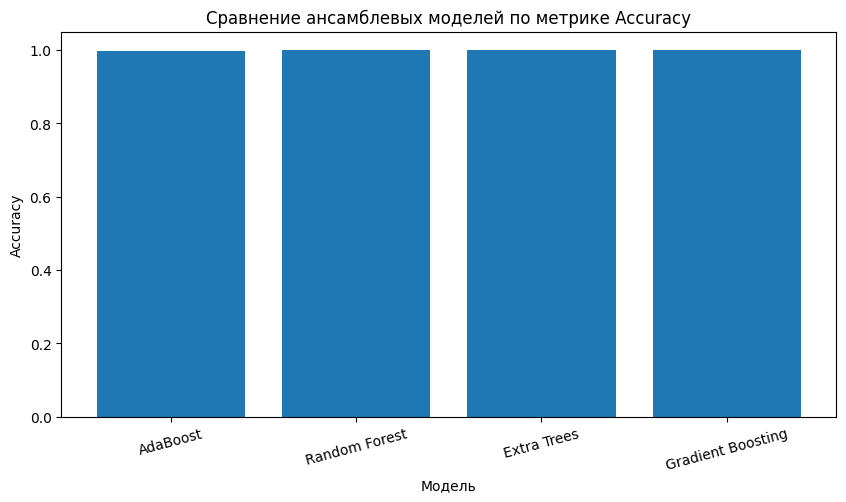

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(results['Модель'], results['Accuracy'])
plt.title('Сравнение ансамблевых моделей по метрике Accuracy')
plt.xlabel('Модель')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.show()